In [2]:
import numpy as np
import scipy.special as scispec

import matplotlib.pyplot as plt

import sys
sys.path.append('../')
import analysis_utils as utils
utils.load_plotting_setting()

In [3]:
def get_c_d_integrals(na):
    thetamax = np.arcsin(na)
    C = 2 * ( 8 / 15 - (np.cos(thetamax)**(3/2) ) / 3 - (np.cos(thetamax)**(5/2) ) / 5 )
    D = 2 * ( 12 / 35 - (np.cos(thetamax)**(5/2) ) / 5 - (np.cos(thetamax)**(7/2) ) / 7 )
    
    return C, D

def calc_geometric_factor(na):
    """Calculate the geometric factor A using Eq. (A3), (E2a) and (E2b) of https://arxiv.org/pdf/1907.12838.pdf"""
    C, D = get_c_d_integrals(na)
    return D / C

In [4]:
hbar = 1.055e-34 # (J / Hz) = (kg * m^2 / s)
c = 299792458    # m / s
pi = np.pi

n1 = 1     # Air refractive index
NA = 0.77  # NA of trapping/collection lens
thetamax = (1./n1) * np.arcsin(NA)  # rad

lam = 1064e-9    # Laser wavelength (m)
k = 2 * np.pi / lam
p_sca = 30e-6  # Scattered laser power (W)
A = calc_geometric_factor(0.77)         # Geometrical factor for z

## Microscope collection efficiency

Compute the photon collection and information efficiency defined by the collection NA, (A28) and (A29) in Lorenzo's paper. We use the coordinates as in Fig. A2 so need to be a little careful of the the angles of the backscattered light. 

In [5]:
theta = np.linspace(0, thetamax, 1000)
theta_full = np.linspace(0, pi, 1000)
phi = np.linspace(0, 2*pi, 1000)

tt, pp = np.meshgrid(np.pi - theta, phi)
tt_full, pp_full = np.meshgrid(np.pi - theta_full, phi)

The probability that a photon emitted by a dipole in direction $\hat{k}$ is
$$
    P(\theta, \phi) = \frac{3}{8 \pi} (\cos^2{\theta} \cos^2{\phi} + \sin^2{\phi}),
$$
so 
$$
    dp_{\mathrm{sca}} (\theta, \phi) = \frac{3}{8 \pi} P_{\mathrm{sca}} [1 - \sin^2{\theta} \cos^2{\phi}]
$$
is the differential scattered power and we've also used $d \Omega = \sin{\theta} d \theta d \phi$ while doing the integral.

In [13]:
dp = (3 / (8*pi)) * p_sca * ( (np.cos(tt)**2) * (np.cos(pp)**2) + np.sin(pp)**2) * np.sin(tt)
dp_full = (3 / (8*pi)) * p_sca * ( (np.cos(tt_full)**2) * (np.cos(pp_full)**2) + np.sin(pp_full)**2 ) * np.sin(tt_full)

phi_int = np.trapz(dp, phi, axis=1)
theta_phi_int = np.trapz(phi_int, theta)

phi_int_full = np.trapz(dp_full, phi, axis=1)
theta_phi_int_full = np.trapz(phi_int_full, theta_full)  # Should agree with `p_sca`

eta_star_dc = theta_phi_int / theta_phi_int_full
print(f'NA = {NA:.2f}, Photon collection efficiency: {eta_star_dc:.3f}')

NA = 0.77, Photon collection efficiency: 0.228


For information loss, we need to compare the imprecision noise in the case of imperfect photon collection to the case of perfect collection.

The differential imprecision noise in $z$ is given by
$$
    s^{\mathrm{imp}}_{zz} (\theta, \phi) = \frac{\hbar c}{4 k (\cos{\theta} -A)^2 \cdot dp_{\mathrm{sca}}},
$$
where $A$ is a geometrical fractor from the Gouy phase shift.

In [10]:
ds_zz_imp = (hbar*c) / ( 4 * k * (( A - np.cos(tt) )**2) * dp)  # -1 because we're looking at backscattered light
ds_zz_imp_full = (hbar*c) / ( 4 * k * (( A - np.cos(tt_full) )**2) * dp_full)

/var/folders/mb/1ggr_wms5jz0l7fkkc3b9xg80000gn/T/ipykernel_4392/889545678.py:2: RuntimeWarning: divide by zero encountered in divide
  ds_zz_imp_full = (hbar*c) / ( 4 * k * (( A - np.cos(tt_full) )**2) * dp_full)


In [14]:
phi_int_imp = np.trapz(1 / ds_zz_imp, phi, axis=1)
theta_phi_int_imp = np.trapz(phi_int_imp, theta)

phi_int_imp_full = np.trapz(1 / ds_zz_imp_full, phi, axis=1)
theta_phi_int_imp_full = np.trapz(phi_int_imp_full, theta_full)

print(f'Imprecision noise: {1 / theta_phi_int_imp:.2e} (m^2/Hz, imperfect), {1 / theta_phi_int_imp_full:.2e} (perfect)')

eta_dc = theta_phi_int_imp / theta_phi_int_imp_full
print(f'Information collection efficiency: {eta_dc:.3f}', )

Imprecision noise: 7.06e-29 (m^2/Hz, imperfect), 4.09e-29 (perfect)
Information collection efficiency: 0.579


## Confocal microscope and dipole image

Our calculation follows Lorenzo's paper and this paper: https://arxiv.org/pdf/physics/0609173.pdf

This paper calculates the electric field of a dipole scatterer imaged by a confocal microscope system onto the fiber tip.

The coordinates $r_1, \theta_1, \phi_1$ are spherical coordinates in the object (dipole) space, while $\rho_3, \phi_3, z_3$ are cylindrical coordinates in the image (fiber) space.

In [41]:
# Polar angle in the object space; `theta_1` in the paperb
theta = np.linspace(0, thetamax, 1000)

# Angle and radius of the fiber tip
phi3 = np.linspace(0, 2 * pi, 100)
rho3 = np.linspace(0, 62.5e-6, 1000)  # Radial distance from fibre axis

In [42]:
epsilon0 = 8.854e-12  # Free space permittivity (SI)
wavelength = 1064e-9  # (m)
omega = 2 * pi * c / wavelength

# Index of the two lenses of the confocal microscope
# In our setup everything is in air
n1 = 1.0
n3 = 1.0
###

k0 = omega / c  # Wavelength in vacuum
k1 = k0 * n1    # Wavenumber in first material
k3 = k0 * n3    # wavenumber in secondimagevalue for now based on a magnification of 8.5 being best

f1 = 3.1e-3    # Focal length of the collection lens
# f3 = f1 * 10.5  # Focal length of the fiber collimator
f3 = 7.5e-3 * 5
M = f3 / f1     # Magnification - f3 is the variable we want to optimise
z3 = 0          # Fiber tip position

Helper functions when doing the integral:
$$
    f(\theta_1) = e^{ik_3 z_3} g(\theta_1) (\cos \theta_1 / g(\theta_1))^{1/2} \sin \theta_1,
$$
and
$$
    g(\theta_1) = [1 - (\sin \theta_1 / M)^2]^{1/2}
$$

In [43]:
def g_theta(theta, M):
    g = (1 - (np.sin(theta) / M)**2)**(1/2)
    return g

def f_theta(theta, M):
    f = np.exp(1j * k3 * z3 * g_theta(theta, M)) * (np.cos(theta)/g_theta(theta, M))**(1/2) * np.sin(theta)
    return f

The $x$, $y$, and $z$ components of the electric field of an $x$-oriented dipole (which is the case for an $x$-polarized trapping beam) in the image space is given by

$$
    E^x_{3, x}(\rho3, \phi3, z_3) = C(f1, f3) \cdot \tilde{I}_{d0} + \tilde{I}_{d2} \cos 2 \phi_3, \\
    E^x_{3, y}(\rho3, \phi3, z_3) = C(f1, f3) \cdot \tilde{I}_{d2} \sin 2 \phi_3, \\
    E^x_{3, z}(\rho3, \phi3, z_3) = C(f1, f3) \cdot -2i \tilde{I}_{d1, 2} \cos \phi_3.
$$

The notation is a little confusing at first sight - these are functions of coordinates in the image space ($\rho3, \phi3, z_3$) but are Cartesian $x$, $y$, and $z$ components.

The numerical factors and integrals are given by

$$
    C(f1, f3) = i k^3_0 (n_1 n_3)^{1/2} e^{i f_1 (k_1 - k3 M)} / (8 \pi M \epsilon_0), \\
    \tilde{I}_{d0} = \int^{\theta^{\mathrm{max}}_1}_0 d \theta_1 f(\theta_1) (1 + \cos \theta_1 g(\theta_1)) J_0, \\
    \tilde{I}_{d1} = \int^{\theta^{\mathrm{max}}_1}_0 d \theta_1 f(\theta_1) g(\theta_1)) \sin \theta_1 J_1, \\
    \tilde{I}_{d1, 2} = \int^{\theta^{\mathrm{max}}_1}_0 d \theta_1 f(\theta_1) \cos \theta_1 \sin \theta_1 M^{-2} J_1.
$$
The $J_m$'s are ordinary Bessel functions with argument $(k_3 \rho_3 / M) \sin \theta_1$.

Notice that the integrals for $\tilde{I}_d$'s are performed with respect to the angle in the object space $\theta_1$. The maximum integration angle is set by the NA of the trapping/collection lens.

In [44]:
C = 1j * k0**3 * (n1 * n3)**(1 / 2) * np.exp(1j * f1 * (k1 - k3 * M)) / (8 * pi * M * epsilon0)
dx = 1  # Dipole moment

In [45]:
Id0, Id2, Id12 = [np.empty_like(rho3, dtype=np.complex128),
                  np.empty_like(rho3, dtype=np.complex128),
                  np.empty_like(rho3, dtype=np.complex128)]
ft = f_theta(theta, M)
gt = g_theta(theta, M)
ct = np.cos(theta)
st = np.sin(theta)
for i, rho in enumerate(rho3):
    arg = 1.3 * k0 * rho / M * np.sin(theta)
    Id0[i] = np.trapz(ft * (1 + ct * gt) * scispec.jv(0, arg), theta) # integrate over theta
    Id2[i] = np.trapz(ft * (1 - ct * gt) * scispec.jv(2, arg), theta)
    Id12[i] = np.trapz(ft * ct * st * M**(-2) * scispec.jv(1, arg), theta)

In [46]:
Ex3_x, Ex3_y, Ex3_z = [np.empty((phi3.size, rho3.size), dtype=np.complex128), 
                           np.empty((phi3.size, rho3.size), dtype=np.complex128), 
                           np.empty((phi3.size, rho3.size), dtype=np.complex128)]
for i, phi in enumerate(phi3):
    Ex3_x[i] = C * dx * (Id0 + Id2 * np.cos(2 * phi) )
    Ex3_y[i] = C * dx * ( Id2 * np.sin(2 * phi) ) 
    Ex3_z[i] = C * dx * (-2j * Id12 * np.cos(phi) )

#### E field in a single mode fiber

The optical property of fiber is completely determined by the core/cladding raidus and refractive indices. Here assume numbers for Thorlabs PM980-XP polarization maintaining fiber

In [47]:
r_core = 2.75e-6  # (m)
r_clad = 62.5e-6

n_core = 1.45562  # @980 nm so not entirely accurate
n_clad = 1.45067

A single mode fiber admits two linearly polarized modes ($LP_{01}$).

For a weakly guided single mode fiber, the $x$-polarized electric field solution is given by

\begin{equation}
\vec{E}^x_{01} (\vec{r}, t) = 
\begin{cases}
    N J_0(\frac{ur}{a}) e^{i \beta z} \hat{n}_x & \text{if $r<a$}, \\
    N \frac{J_0(u)}{K_0(w)} K_0(\frac{wr}{a}) e^{i \beta z} \hat{n}_x & \text{if $r>a$}.
\end{cases}
\end{equation}

Note the E-field is always pointing in the $x$-direction. For the y-polarized field, just replace $x$ by $y$.
$N$ is just a normalization factor and we will ignore it in the calculation.

We assume the fiber tip is at $z_3$ = 0 so the function is purely real.

In [48]:
def get_fiber_e_field(r_core, r_clad, n_core, n_clad):
    """
    Fiber E field distribution, assume x-polarized.
    """
    # Calculate mode parameters `u`, `w`, and `beta`
    v = r_core * k0 * np.sqrt(n_core**2 - n_clad**2)
    uu = np.linspace(0, v*0.999, 10000)
    ww = np.sqrt(v**2 - np.square(uu))  # Using V^2 = u^2 + w^2

    diff_abs = np.abs(uu * scispec.j1(uu) / scispec.j0(uu) - ww * scispec.k1(ww) / scispec.k0(ww))
    u = uu[np.argmin(diff_abs)]
    w = np.sqrt(v**2 - np.square(u))
    beta  = np.sqrt(n_core**2 * k0**2 - u**2 / r_core**2)
    
    # Calculate E-field in fiber
    r1 = np.linspace(0, r_core, 1000)      # Radius in core
    r2 = np.linspace(r_core, r_clad, 9000) # Radius in cladding

    rr1, pp1 = np.meshgrid(r1, phi3)       # (r, phi) coordinates
    rr2, pp2 = np.meshgrid(r2, phi3)

    Ex_01_in = scispec.jv(0, u * rr1 / r_core)    # E field in core, r < a
    Ex_01_out = scispec.jv(0, u) / scispec.kv(0, w) * scispec.kv(0, w * rr2 / r_core) # E field in cladding, r > a
    
    r_full = np.concatenate([r1, r2])
    Ex_01_full = np.concatenate([ Ex_01_in, Ex_01_out ], axis=1)

    # Resample E field
    Ex_01_full_interp = np.empty_like(Ex3_x)

    # Loop over phi values
    for i in range(Ex3_x.shape[0]):
        Ex_01_full_interp[i] = np.interp(rho3, r_full, Ex_01_full[i])
    
    return rho3, Ex_01_full_interp

In [49]:
r_fiber, e_fiber = get_fiber_e_field(r_core, r_clad, n_core, n_clad)

Plot fiber E-field and the real part of dipole E-field at a fixed angle:

/Users/yuhan/anaconda3/envs/nanospheres/lib/python3.12/site-packages/matplotlib/cbook.py:1699: ComplexWarning: Casting complex values to real discards the imaginary part
  return math.isfinite(val)
/Users/yuhan/anaconda3/envs/nanospheres/lib/python3.12/site-packages/matplotlib/cbook.py:1345: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


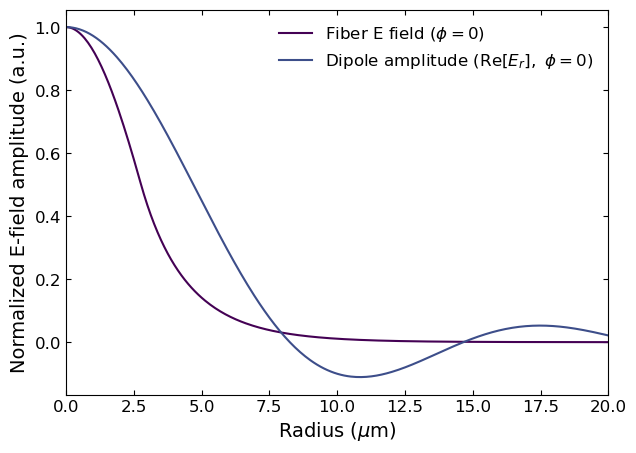

In [51]:
plt.plot(r_fiber * 1e6, e_fiber[0], label=r'Fiber E field ($\phi=0$)')
plt.plot(rho3 * 1e6, Ex3_x[0] / Ex3_x[0][0], label=r'Dipole amplitude ($\mathrm{Re}[E_r],~\phi = 0$)')

plt.xlim(0, 20)
plt.ylabel(r'Normalized E-field amplitude (a.u.)')
plt.xlabel(r'Radius ($\mu$m)')
plt.legend(frameon=False, fontsize=12)

plt.savefig('efield_fiber_dipole.pdf', dpi=300)

## Collection efficiency

The collection efficiency is calculated by
$$
    \eta(M) = \frac{| \int \vec{E}^*_{\mathrm{dipole}} \cdot \vec{E}_{\mathrm{fiber}} dA_3|^2}{ \int | \vec{E}_{\mathrm{dipole}}^2 dA_3 \int | \vec{E}_{\mathrm{fiber}}|^2 dA_3}
$$

A single mode fiber supports two linearly polarized modes, so we calculate the overlap integral for the $x-$ and $y-$ polarized modes separately. The total collection efficiency is given by the sum of the two, $\eta = \eta^x + \eta^y$.

Calculate the overlap integral

In [21]:
int_num_x = np.conjugate(Ex3_x) * Ex_01_full_interp
overlap_x = np.abs(np.trapz( np.trapz(int_num_x * rho3, rho3, axis=1), phi3)) ** 2

E3x_int = np.trapz( np.trapz( (np.abs(Ex3_x)**2)*rho3, rho3, axis=1), phi3)
Ex_int = np.trapz( np.trapz( (np.abs(Ex_01_full_interp)**2)*rho3, rho3, axis=1), phi3)

In [22]:
int_num_y = np.conjugate(Ex3_y) * Ex_01_full_interp
overlap_y = np.abs(np.trapz( np.trapz(int_num_y * rho3, rho3, axis=1), phi3)) ** 2

E3y_int = np.trapz( np.trapz( (np.abs(Ex3_y)**2)*rho3, rho3, axis=1), phi3)

In [23]:
eta_x = overlap_x / (E3x_int * Ex_int)
eta_y = overlap_y / (E3y_int * Ex_int)

In [24]:
print(f'Collection efficiency (x): {eta_x:.3f}')
print(f'Collection efficiency (y): {eta_y:.3f}')

print(f'Total collection efficiency: {eta_x + eta_y:.3f}')

Collection efficiency (x): 0.729
Collection efficiency (y): 0.000
Total collection efficiency: 0.729


## Collection efficiency for different magnifications

In [25]:
def get_efficiency(na, f1, f3, e_fiber):
    thetamax = (1./n1) * np.arcsin(na)  # rad
    theta = np.linspace(0, thetamax, 1000)

    M = f3 / f1
    
    C = 1j * k0**3 * (n1 * n3)**(1 / 2) * np.exp(1j * f1 * (k1 - k3 * M)) / (8 * pi * M * epsilon0)
    dx = 1  # Dipole moment
    
    Id0, Id2, Id12 = [np.empty_like(rho3, dtype=np.complex128),
                      np.empty_like(rho3, dtype=np.complex128),
                      np.empty_like(rho3, dtype=np.complex128)]
    ft = f_theta(theta, M)
    gt = g_theta(theta, M)
    ct = np.cos(theta)
    st = np.sin(theta)
    for i, rho in enumerate(rho3):
        arg = 1.3 * k0 * rho / M * np.sin(theta)
        Id0[i] = np.trapz(ft * (1 + ct * gt) * scispec.jv(0, arg), theta) # integrate over theta
        Id2[i] = np.trapz(ft * (1 - ct * gt) * scispec.jv(2, arg), theta)
        Id12[i] = np.trapz(ft * ct * st * M**(-2) * scispec.jv(1, arg), theta)
        
    Ex3_x, Ex3_y, Ex3_z = [np.empty((phi3.size, rho3.size), dtype=np.complex128), 
                           np.empty((phi3.size, rho3.size), dtype=np.complex128), 
                           np.empty((phi3.size, rho3.size), dtype=np.complex128)]
    
    for i, phi in enumerate(phi3):
        Ex3_x[i] = C * dx * (Id0 + Id2 * np.cos(2 * phi) )
        Ex3_y[i] = C * dx * ( Id2 * np.sin(2 * phi) ) 
        Ex3_z[i] = C * dx * (-2j * Id12 * np.sin(2 * phi) )
    
    # Calculate overlap for both x and y polarization
    int_num_x = np.conjugate(Ex3_x) * e_fiber
    overlap_x = np.abs(np.trapz( np.trapz(int_num_x * rho3, rho3, axis=1), phi3)) ** 2
    int_num_y = np.conjugate(Ex3_y) * e_fiber
    overlap_y = np.abs(np.trapz( np.trapz(int_num_y * rho3, rho3, axis=1), phi3)) ** 2
    
    E3x_int = np.trapz( np.trapz( (np.abs(Ex3_x)**2)*rho3, rho3, axis=1), phi3)
    E3y_int = np.trapz( np.trapz( (np.abs(Ex3_y)**2)*rho3, rho3, axis=1), phi3)
    Ex_int = np.trapz( np.trapz( (np.abs(e_fiber)**2)*rho3, rho3, axis=1), phi3)
    
    eta_x = overlap_x / (E3x_int * Ex_int)
    eta_y = overlap_y / (E3y_int * Ex_int)
    
    return eta_x + eta_y

Redo the calculation for polarization maintaining PM980-XP fiber.

In [40]:
r_core = 2.75e-6  # (m)
r_clad = 62.5e-6

n_core = 1.45562  # @980 nm so not entirely accurate
n_clad = 1.45067

In [ ]:
r_fiber, e_fiber = get_fiber_e_field(r_core, r_clad, n_core, n_clad)

ff = np.linspace(2*f1_actual, 20*f1_actual, 30)
eff = np.empty_like(ff)
for i, f in enumerate(ff):
    eff[i] = get_efficiency(na_actual, f1_actual, f, e_fiber)

In [ ]:
f_max = ff[ np.where(eff==np.max(eff))[0][0] ]
print(f'Maximum collection efficiency: {np.max(eff):.3f} at M = {f_max/f1_actual:.3f}')

f3_actual = 7.5e-3 * 5
print(f'Actual collection efficiency (PAF2-7C): {np.interp(f3_actual/f1_actual, ff/f1_actual, eff)}')

Maximum collection efficiency: 0.767 at M = 8.828
Actual collection efficiency (PAF2-7C): 0.6942122735043408


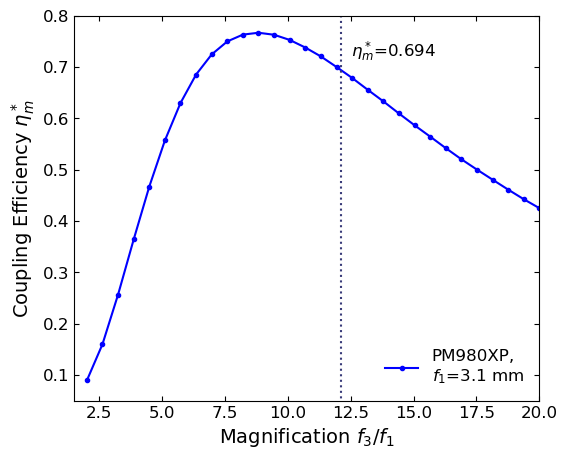

In [109]:
plt.subplots(1, 1, figsize=(6, 5))

plt.plot(ff / f1_actual, eff, 'b.-', label='PM980XP,\n'+r'$f_1$=3.1 mm')
plt.vlines(f3_actual/f1_actual, 0, 1, linestyles=':')

plt.text(12.5, 0.72, fr'$\eta_m^*$={np.interp(f3_actual/f1_actual, ff/f1_actual, eff):.3f}', fontsize=12)
plt.xlim(1.5, 20)
plt.ylim(0.05, 0.8)
plt.xlabel(r'Magnification $f_3 / f_1$', fontsize=14)
plt.ylabel(r'Coupling Efficiency $\eta_m^*$', fontsize=14)
plt.legend(frameon=False, loc=4)

In [97]:
NA = 0.77  # NA of trapping/collection lens
thetamax = (1./n1) * np.arcsin(NA)  # rad

theta = np.linspace(0, thetamax, 1000)
theta_full = np.linspace(0, pi, 1000)
phi = np.linspace(0, 2*pi, 1000)

tt, pp = np.meshgrid(np.pi - theta, phi)
tt_full, pp_full = np.meshgrid(np.pi - theta_full, phi)

dp = (3 / (8*pi)) * p_sca * ( (np.cos(tt)**2) * (np.cos(pp)**2) + np.sin(pp)**2) * np.sin(tt)
dp_full = (3 / (8*pi)) * p_sca * ( (np.cos(tt_full)**2) * (np.cos(pp_full)**2) + np.sin(pp_full)**2 ) * np.sin(tt_full)

phi_int = np.trapz(dp, phi, axis=1)
theta_phi_int = np.trapz(phi_int, theta)

phi_int_full = np.trapz(dp_full, phi, axis=1)
theta_phi_int_full = np.trapz(phi_int_full, theta_full)

eta_star_dc = theta_phi_int / theta_phi_int_full
print(f'Photon collection efficiency (NA=0.77): {eta_star_dc:.3f}')

Photon collection efficiency (NA=0.77): 0.228


In [100]:
A = calc_geometric_factor(na=0.77)
p_sca = 16.96e-6
dp = (3 / (8*pi)) * p_sca * ( (np.cos(tt)**2) * (np.cos(pp)**2) + np.sin(pp)**2) * np.sin(tt)

ds_zz_imp = (hbar*c) / ( 4 * k * (( A - np.cos(tt) )**2) * dp)  # -1 because we're looking at backscattered light
ds_zz_imp_full = (hbar*c) / ( 4 * k * (( A - np.cos(tt_full) )**2) * dp_full)

phi_int_imp = np.trapz(1 / ds_zz_imp, phi, axis=1)
theta_phi_int_imp = np.trapz(phi_int_imp, theta)

phi_int_imp_full = np.trapz(1 / ds_zz_imp_full, phi, axis=1)
theta_phi_int_imp_full = np.trapz(phi_int_imp_full, theta_full)

print(f'Imprecision noise (double-sided): {1 / theta_phi_int_imp:.2e} (m^2/Hz, imperfect), {1 / theta_phi_int_imp_full:.2e} (perfect)')
eta_dc = theta_phi_int_imp / theta_phi_int_imp_full
print(f'Information collection efficiency (NA=0.77): {eta_dc:.3f}')

Imprecision noise (double-sided): 1.25e-28 (m^2/Hz, imperfect), 7.23e-29 (perfect)
Information collection efficiency (NA=0.77): 0.579


/var/folders/mb/1ggr_wms5jz0l7fkkc3b9xg80000gn/T/ipykernel_20950/3595080830.py:6: RuntimeWarning: divide by zero encountered in divide
  ds_zz_imp_full = (hbar*c) / ( 4 * k * (( A - np.cos(tt_full) )**2) * dp_full)


In [118]:
print(f'Total information collection efficiency (assume no loss): {0.694 * eta_dc:.3f}')

Total information collection efficiency (assume no loss): 0.402
